<a href="https://colab.research.google.com/github/subuhang/AI-and-Machine-Learning/blob/main/Vision_Task_PartII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part II – Vision Task: Image Classification with CNN and Transfer Learning

**6CS012 Artificial Intelligence and Machine Learning – Final Integrated Assessment**

This notebook is prepared for **Part II: Vision Task**. It follows the required structure:

- Data understanding, visualization, preprocessing, and augmentation
- Baseline CNN from scratch with 3 convolutional blocks and 3 fully connected layers
- Deeper CNN with regularization
- Optimizer comparison: Adam vs SGD
- Ablation study
- Transfer learning using a pretrained CNN
- Final comparison and sample predictions

> Update only the dataset path in Section 0 before running.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# 0. INSTALLS / IMPORTS / CONFIGURATION
# ============================================================
import os
import time
import math
import shutil
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 0.1 Dataset path setup

Use one of the options below.

### Option A: Dataset already extracted in Colab
Set `DATASET_ROOT` to the folder that contains either:

```text
DATASET_ROOT/
  Train/
    class_1/
    class_2/
  Test/
    class_1/
    class_2/
```

or:

```text
DATASET_ROOT/
  class_1/
  class_2/
  class_3/
```

### Option B: Dataset zip stored in Google Drive
Uncomment the Drive mounting and unzip section.

In [3]:
# ============================================================
# 0.1 DATASET PATH SETUP
# ============================================================

DATASET_ROOT = '/content/drive/MyDrive/AI & Machine Learning/Coursework/Coursework/Skin Cancer Classification'
# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.20
EPOCHS_SCRATCH = 20
EPOCHS_TRANSFER_HEAD = 10
EPOCHS_TRANSFER_FINE = 10

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def count_images(folder):
    folder = Path(folder)
    if not folder.exists():
        return 0
    return sum(1 for p in folder.rglob('*') if p.suffix.lower() in VALID_EXTS)

def find_train_test_dirs(root):
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f'Dataset root not found: {root}. Please update DATASET_ROOT.')

    # Common folder names
    train_candidates = ['Train', 'train', 'Training', 'training']
    test_candidates = ['Test', 'test', 'Testing', 'testing', 'valid', 'Validation', 'validation']

    train_dir = None
    test_dir = None
    for name in train_candidates:
        if (root / name).exists():
            train_dir = root / name
            break
    for name in test_candidates:
        if (root / name).exists():
            test_dir = root / name
            break

    # If no Train/Test folders, assume root itself contains class folders
    if train_dir is None:
        train_dir = root

    return str(train_dir), str(test_dir) if test_dir is not None else None

TRAIN_DIR, TEST_DIR = find_train_test_dirs(DATASET_ROOT)
print('TRAIN_DIR:', TRAIN_DIR)
print('TEST_DIR :', TEST_DIR)
print('Training image count:', count_images(TRAIN_DIR))
if TEST_DIR:
    print('Test image count:', count_images(TEST_DIR))
else:
    print('No separate test folder detected. Validation split will be used from training folder.')

TRAIN_DIR: /content/drive/MyDrive/AI & Machine Learning/Coursework/Coursework/Skin Cancer Classification/Train
TEST_DIR : /content/drive/MyDrive/AI & Machine Learning/Coursework/Coursework/Skin Cancer Classification/Test
Training image count: 2176
Test image count: 118


## 1. Data Understanding, Analysis, Visualization and Cleaning

This section checks the dataset structure, counts images per class, visualizes class distribution, displays sample images, and prepares Keras data generators.

In [4]:
# ============================================================
# 1.1 DATASET EXPLORATION
# ============================================================

class_names = sorted([
    d.name for d in Path(TRAIN_DIR).iterdir()
    if d.is_dir() and count_images(d) > 0
])

if len(class_names) < 2:
    raise ValueError('At least two class folders are required inside TRAIN_DIR.')

num_classes = len(class_names)
print(f'Number of classes: {num_classes}')
print('Class names:', class_names)

train_counts = {cls: count_images(Path(TRAIN_DIR) / cls) for cls in class_names}

test_counts = None
if TEST_DIR is not None:
    test_counts = {cls: count_images(Path(TEST_DIR) / cls) for cls in class_names if (Path(TEST_DIR) / cls).exists()}

train_total = sum(train_counts.values())
print(f'\nTotal training images: {train_total}')
for cls, n in train_counts.items():
    print(f'{cls}: {n} images ({n/train_total*100:.2f}%)')

if test_counts:
    test_total = sum(test_counts.values())
    print(f'\nTotal test images: {test_total}')
    for cls, n in test_counts.items():
        print(f'{cls}: {n} images ({n/test_total*100:.2f}%)')

Number of classes: 9
Class names: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']

Total training images: 2176
actinic keratosis: 107 images (4.92%)
basal cell carcinoma: 369 images (16.96%)
dermatofibroma: 88 images (4.04%)
melanoma: 431 images (19.81%)
nevus: 350 images (16.08%)
pigmented benign keratosis: 455 images (20.91%)
seborrheic keratosis: 70 images (3.22%)
squamous cell carcinoma: 174 images (8.00%)
vascular lesion: 132 images (6.07%)

Total test images: 118
actinic keratosis: 16 images (13.56%)
basal cell carcinoma: 16 images (13.56%)
dermatofibroma: 16 images (13.56%)
melanoma: 16 images (13.56%)
nevus: 16 images (13.56%)
pigmented benign keratosis: 16 images (13.56%)
seborrheic keratosis: 3 images (2.54%)
squamous cell carcinoma: 16 images (13.56%)
vascular lesion: 3 images (2.54%)


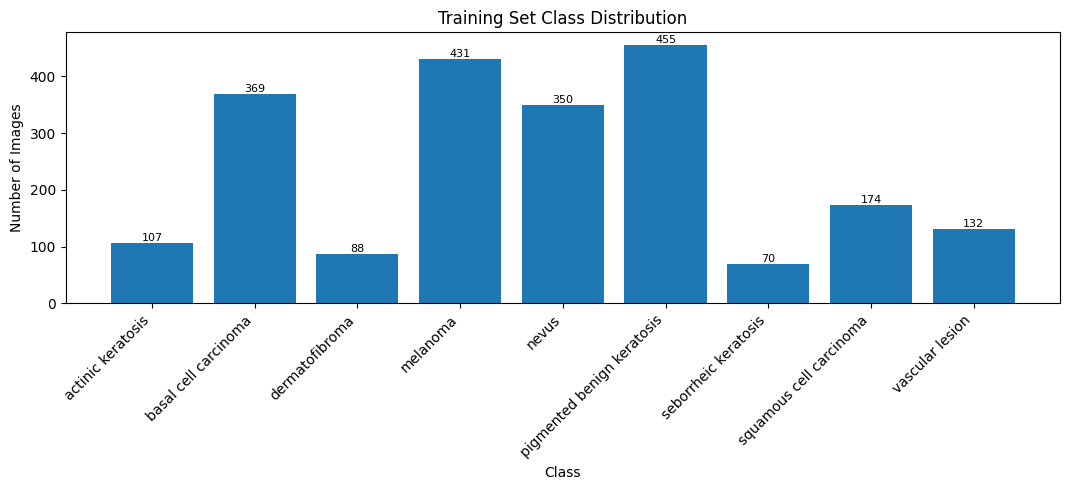

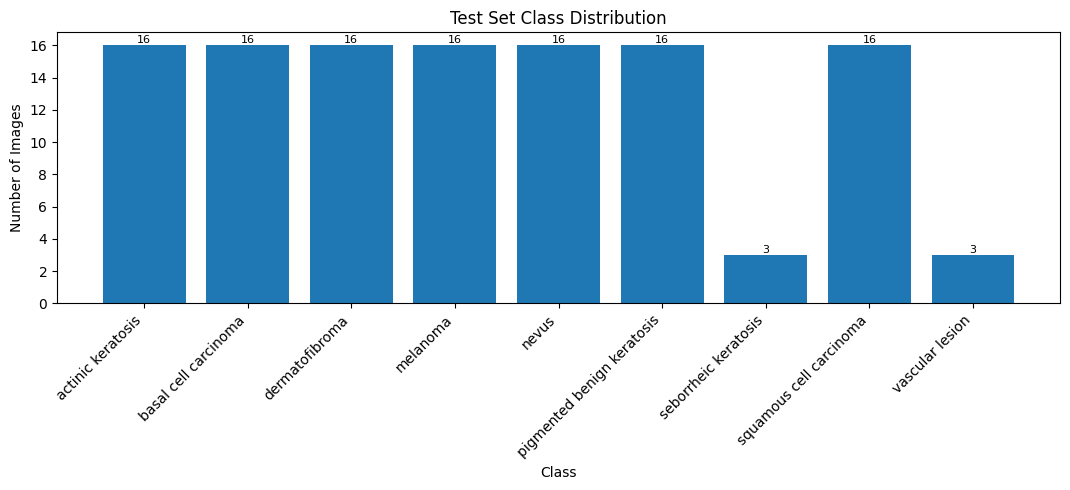

In [5]:
# ============================================================
# 1.2 CLASS DISTRIBUTION VISUALIZATION
# ============================================================

def add_bar_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, str(int(height)),
                ha='center', va='bottom', fontsize=8)

plt.figure(figsize=(max(8, num_classes * 1.2), 5))
bars = plt.bar(list(train_counts.keys()), list(train_counts.values()))
add_bar_labels(plt.gca(), bars)
plt.title('Training Set Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_distribution_train.png', dpi=150, bbox_inches='tight')
plt.show()

if test_counts:
    plt.figure(figsize=(max(8, num_classes * 1.2), 5))
    bars = plt.bar(list(test_counts.keys()), list(test_counts.values()))
    add_bar_labels(plt.gca(), bars)
    plt.title('Test Set Class Distribution')
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('class_distribution_test.png', dpi=150, bbox_inches='tight')
    plt.show()

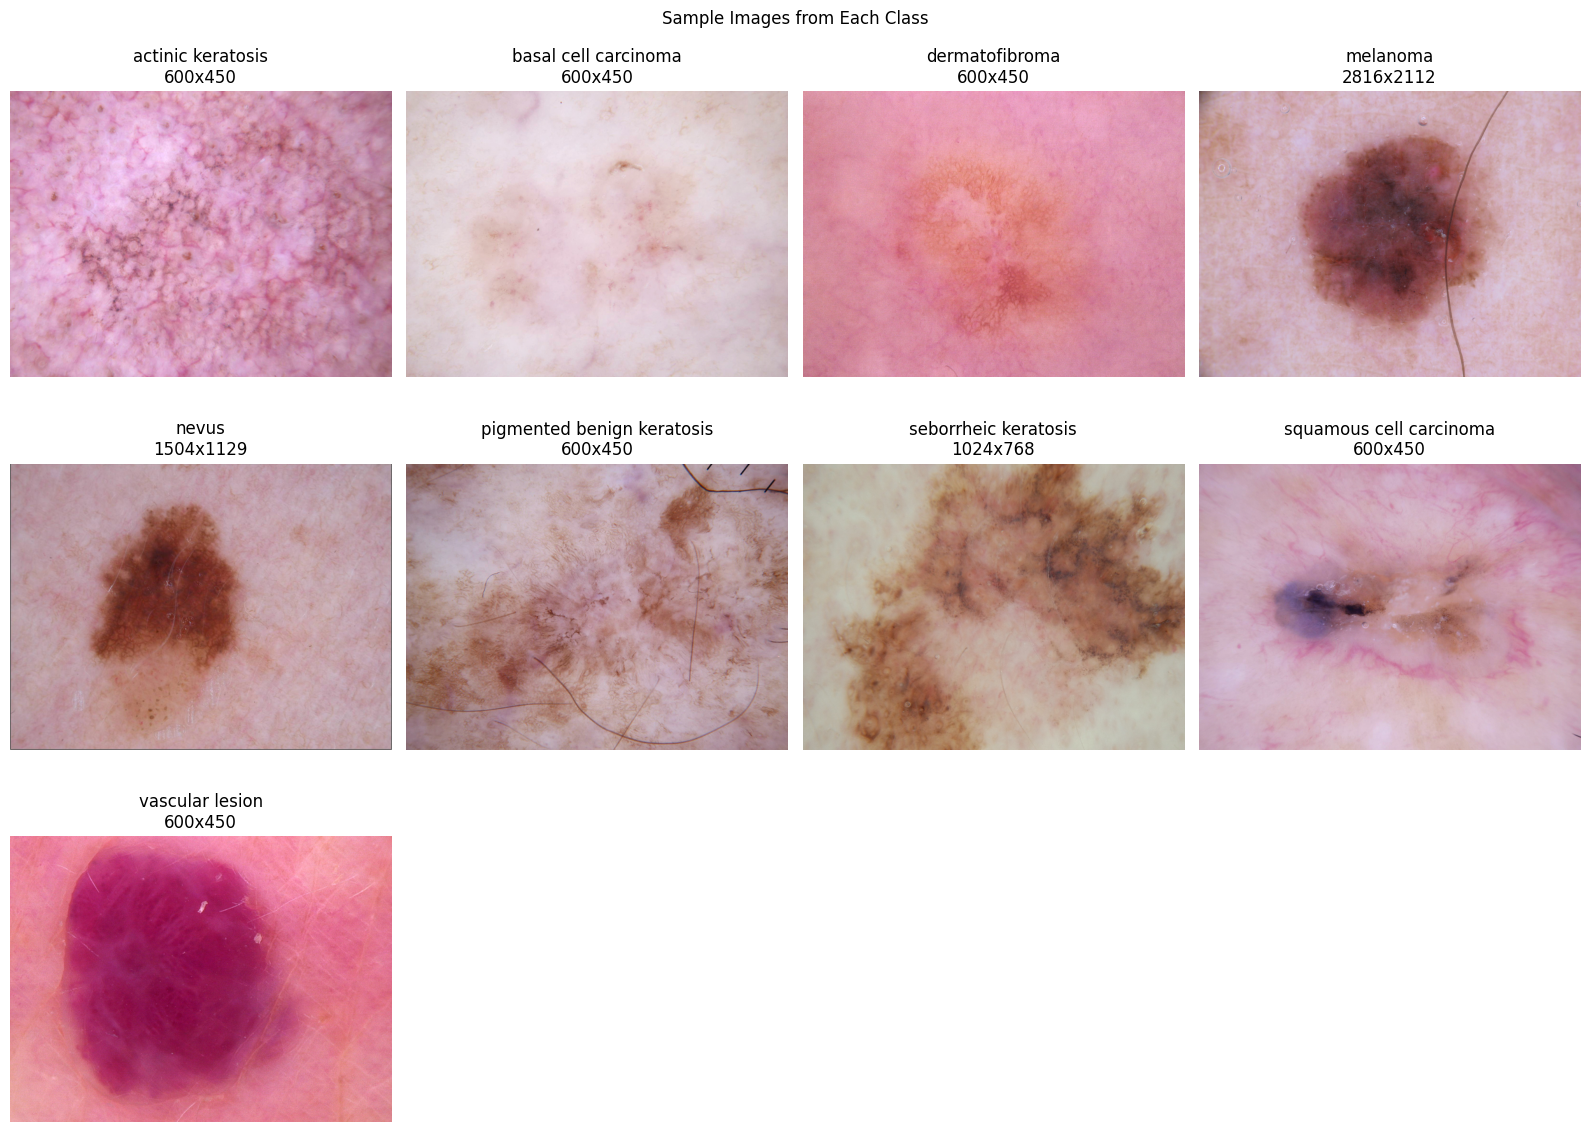

In [6]:
# ============================================================
# 1.3 SAMPLE IMAGES FROM EACH CLASS
# ============================================================

cols = min(4, num_classes)
rows = math.ceil(num_classes / cols)
plt.figure(figsize=(4 * cols, 4 * rows))

for i, cls in enumerate(class_names):
    cls_dir = Path(TRAIN_DIR) / cls
    images = [p for p in cls_dir.iterdir() if p.suffix.lower() in VALID_EXTS]
    if not images:
        continue
    img_path = images[0]
    img = load_img(img_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f'{cls}\n{img.size[0]}x{img.size[1]}')
    plt.axis('off')

plt.suptitle('Sample Images from Each Class')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# 1.4 DATA GENERATORS AND PREPROCESSING
# ============================================================

# Training generator uses augmentation.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=VAL_SPLIT
)

# Validation generator should not use augmentation. It only rescales.
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

if TEST_DIR:
    test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
else:
    # If no test folder exists, use validation generator for final evaluation.
    test_generator = val_generator

class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)
print('Class labels:', class_labels)
print('Train samples:', train_generator.samples)
print('Validation samples:', val_generator.samples)
print('Test samples:', test_generator.samples)

Found 1744 images belonging to 9 classes.
Found 432 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
Class labels: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Train samples: 1744
Validation samples: 432
Test samples: 118


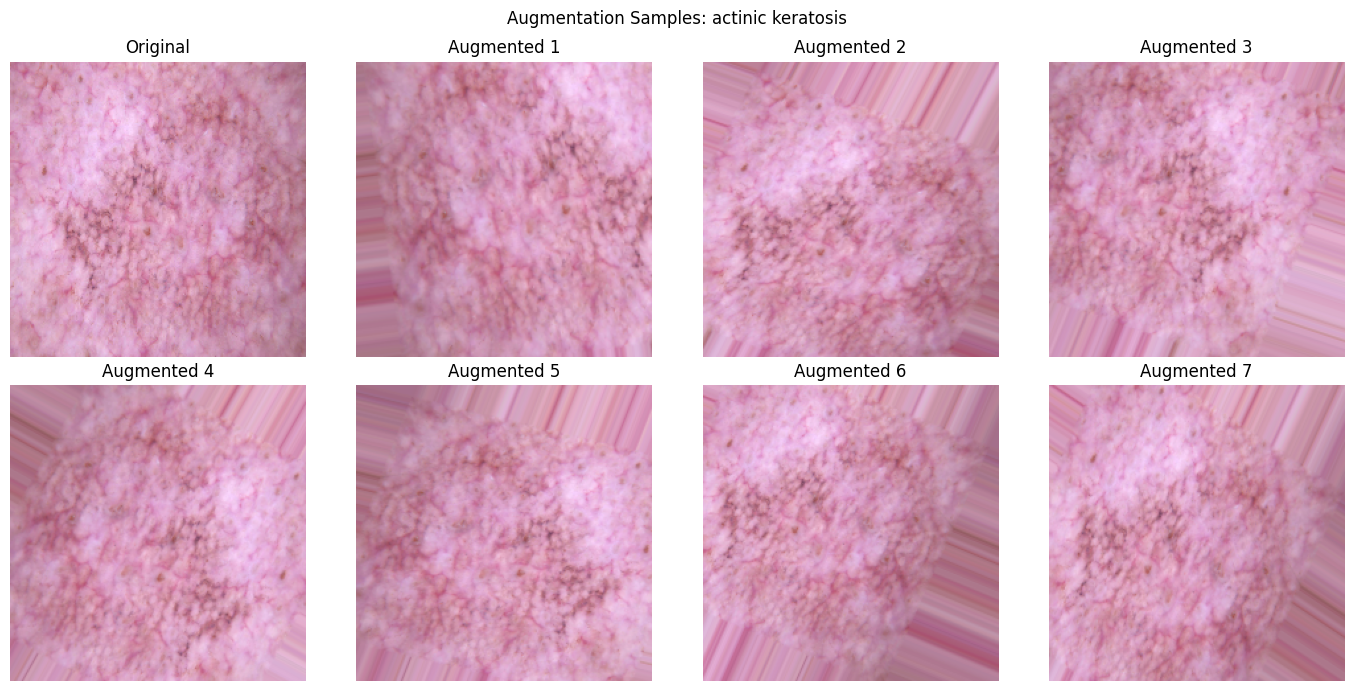

In [8]:
# ============================================================
# 1.5 AUGMENTED IMAGE VISUALIZATION
# ============================================================

sample_class = class_labels[0]
sample_dir = Path(TRAIN_DIR) / sample_class
sample_images = [p for p in sample_dir.iterdir() if p.suffix.lower() in VALID_EXTS]
sample_img_path = sample_images[0]

img = load_img(sample_img_path, target_size=IMG_SIZE)
img_array = img_to_array(img)

aug_only_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    fill_mode='nearest'
)

plt.figure(figsize=(14, 7))
plt.subplot(2, 4, 1)
plt.imshow(img_array.astype('uint8'))
plt.title('Original')
plt.axis('off')

aug_iter = aug_only_datagen.flow(np.expand_dims(img_array, 0), batch_size=1, seed=SEED)
for i in range(7):
    aug_img = next(aug_iter)[0]
    plt.subplot(2, 4, i + 2)
    plt.imshow(aug_img.astype('uint8'))
    plt.title(f'Augmented {i+1}')
    plt.axis('off')

plt.suptitle(f'Augmentation Samples: {sample_class}')
plt.tight_layout()
plt.savefig('augmentation_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Baseline CNN Model

The baseline follows the required architecture: **3 convolutional layers**, pooling after each convolutional layer, **3 fully connected layers**, and a softmax output layer.

In [9]:
# ============================================================
# 2.1 BASELINE CNN MODEL
# ============================================================

def build_baseline_model(input_shape=(224, 224, 3), num_classes=num_classes):
    model = Sequential(name='Baseline_CNN')
    model.add(Input(shape=input_shape))

    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1'))
    model.add(MaxPooling2D((2, 2), name='pool1'))

    model.add(Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'))
    model.add(MaxPooling2D((2, 2), name='pool2'))

    model.add(Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'))
    model.add(MaxPooling2D((2, 2), name='pool3'))

    model.add(Flatten(name='flatten'))
    model.add(Dense(256, activation='relu', name='fc1'))
    model.add(Dense(128, activation='relu', name='fc2'))
    model.add(Dense(64, activation='relu', name='fc3'))
    model.add(Dense(num_classes, activation='softmax', name='output'))
    return model

baseline_model = build_baseline_model(input_shape=IMG_SIZE + (3,), num_classes=num_classes)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,825,353 (98.52 MB)

 Trainable params: 25,825,353 (98.52 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
import os

DATASET_ROOT = "/content/drive/MyDrive/AI & Machine Learning/Coursework/Coursework/Skin Cancer Classification"

TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR = os.path.join(DATASET_ROOT, "Test")

print("TRAIN_DIR exists:", os.path.exists(TRAIN_DIR))
print("TEST_DIR exists:", os.path.exists(TEST_DIR))

print("\nTrain folders:")
print(os.listdir(TRAIN_DIR))

print("\nTest folders:")
print(os.listdir(TEST_DIR))


TRAIN_DIR exists: True
TEST_DIR exists: True

Train folders:
['dermatofibroma', 'vascular lesion', 'basal cell carcinoma', 'squamous cell carcinoma', 'seborrheic keratosis', 'actinic keratosis', 'nevus', 'melanoma', 'pigmented benign keratosis']

Test folders:
['dermatofibroma', 'seborrheic keratosis', 'squamous cell carcinoma', 'nevus', 'actinic keratosis', 'vascular lesion', 'basal cell carcinoma', 'pigmented benign keratosis', 'melanoma']


In [11]:
from PIL import Image
import os

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp')
bad_files = []

for folder in [TRAIN_DIR, TEST_DIR]:
    for root, dirs, files in os.walk(folder):
        for file in files:
            file_path = os.path.join(root, file)

            if file.startswith('.') or not file.lower().endswith(valid_extensions):
                bad_files.append(file_path)
                continue

            try:
                with Image.open(file_path) as img:
                    img = img.convert("RGB")
                    img.load()
            except Exception as e:
                bad_files.append(file_path)
                print("Bad file:", file_path)
                print("Reason:", e)

print("Total bad/non-image files found:", len(bad_files))

Total bad/non-image files found: 0


In [12]:
for f in bad_files:
    try:
        os.remove(f)
        print("Removed:", f)
    except Exception as e:
        print("Could not remove:", f, e)

print("Cleaning completed.")

Cleaning completed.


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.20,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes

print("Classes:", train_generator.class_indices)
print("Number of classes:", num_classes)
print("Training images:", train_generator.samples)
print("Validation images:", val_generator.samples)
print("Test images:", test_generator.samples)

Found 1744 images belonging to 9 classes.
Found 432 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
Classes: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}
Number of classes: 9
Training images: 1744
Validation images: 432
Test images: 118


In [14]:

# ============================================================
# 2.2 TRAIN BASELINE MODEL
# ============================================================

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('baseline_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

start_time = time.time()
baseline_history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_SCRATCH,
    callbacks=callbacks_baseline,
    verbose=1
)
baseline_training_time = time.time() - start_time
print(f'Baseline training time: {baseline_training_time:.2f} seconds')

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.2289 - loss: 2.0638
Epoch 1: val_accuracy improved from None to 0.21759, saving model to baseline_best.keras

Epoch 1: finished saving model to baseline_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.2919 - loss: 1.9379 - val_accuracy: 0.2176 - val_loss: 2.2565 - learning_rate: 0.0010
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.3219 - loss: 1.8918
Epoch 2: val_accuracy improved from 0.21759 to 0.34028, saving model to baseline_best.keras

Epoch 2: finished saving model to baseline_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 50s 921ms/step - accuracy: 0.3532 - loss: 1.8023 - val_accuracy: 0.3403 - val_loss: 1.7739 - learning_rate: 0.0010
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.4078 - loss: 1.6094
Epoch 3: val_accuracy improved from 0.34028 to 0.41898, saving model to baseline_best.keras

Epoch 3: finished saving model to baseline_best.keras
55/55 ━━━━━━━━━━━━━━━━━

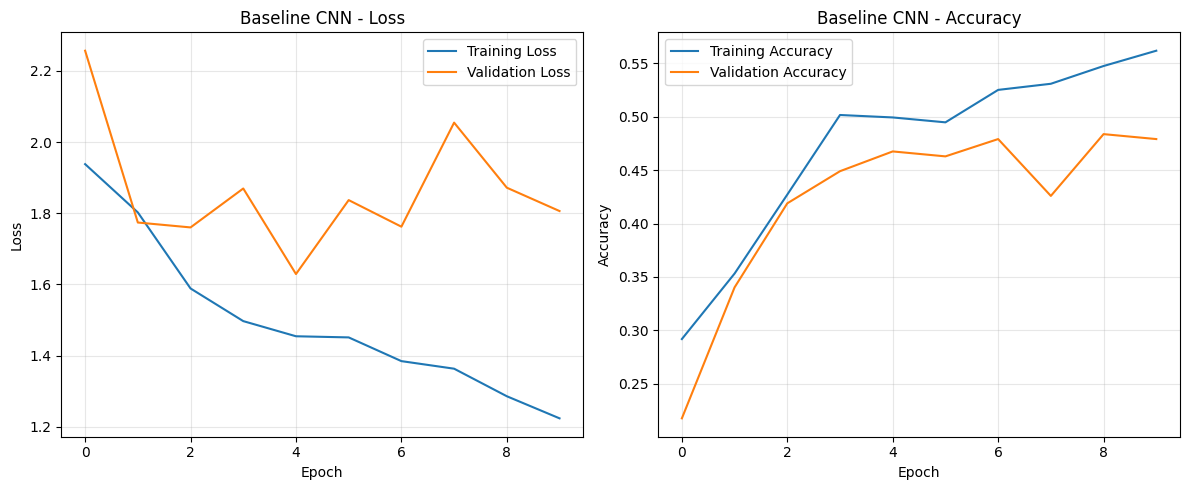

In [15]:
# ============================================================
# 2.3 BASELINE TRAINING CURVES
# ============================================================

def plot_history(history, title, filename):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title + ' - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title + ' - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(baseline_history, 'Baseline CNN', 'baseline_curves.png')


Baseline CNN Results
------------------------------------------------------------
Loss      : 2.1164
Accuracy  : 0.3051
Precision : 0.2862
Recall    : 0.3051
F1-score  : 0.2220

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       1.00      0.12      0.22        16
      basal cell carcinoma       0.35      0.56      0.43        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.00      0.00      0.00        16
                     nevus       0.43      0.62      0.51        16
pigmented benign keratosis       0.24      0.81      0.37        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       0.50      0.67      0.57         3

                  accuracy                           0.31       118
                 macro avg       0.28      0.31 

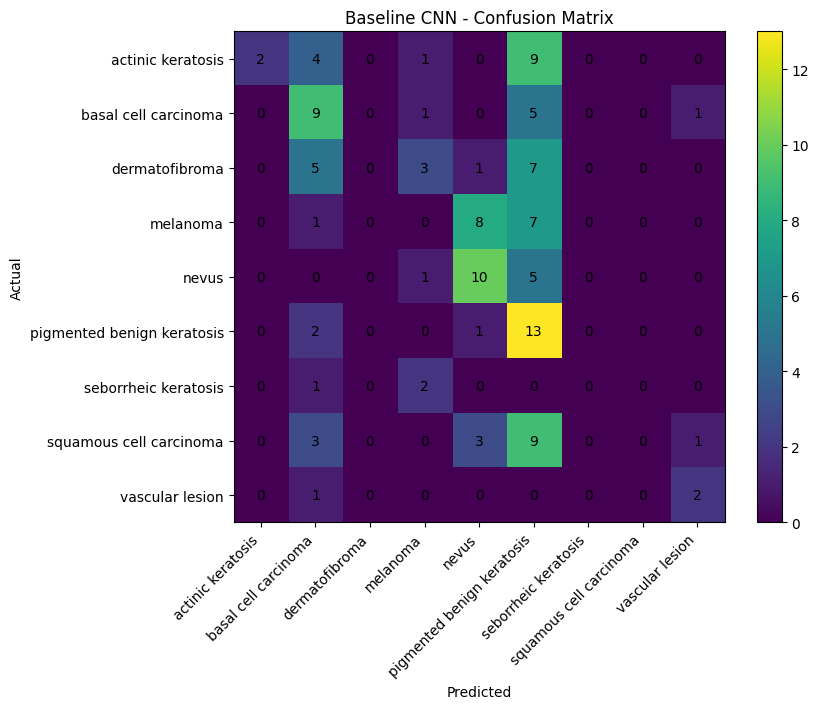

In [16]:
# ============================================================
# 2.4 EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, generator, model_name):
    generator.reset()
    loss, acc = model.evaluate(generator, verbose=0)
    generator.reset()
    preds = model.predict(generator, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = generator.classes

    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f'\n{model_name} Results')
    print('-' * 60)
    print(f'Loss      : {loss:.4f}')
    print(f'Accuracy  : {acc:.4f}')
    print(f'Precision : {precision:.4f}')
    print(f'Recall    : {recall:.4f}')
    print(f'F1-score  : {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_labels, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(7, num_classes), max(6, num_classes * 0.8)))
    plt.imshow(cm, interpolation='nearest')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(num_classes)
    plt.xticks(tick_marks, class_labels, rotation=45, ha='right')
    plt.yticks(tick_marks, class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'), ha='center', va='center')

    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'model': model_name, 'loss': loss, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'y_true': y_true, 'y_pred': y_pred, 'pred_probs': preds}

baseline_results = evaluate_model(baseline_model, test_generator, 'Baseline CNN')

## 3. Deeper CNN with Regularization

The deeper model uses more convolutional layers than the baseline and applies **Batch Normalization** and **Dropout** to reduce overfitting.

In [17]:
# ============================================================
# 3.1 DEEPER CNN MODEL WITH REGULARIZATION
# ============================================================

def build_deeper_model(input_shape=(224, 224, 3), num_classes=num_classes, dropout=True, batch_norm=True):
    model = Sequential(name='Deeper_CNN')
    model.add(Input(shape=input_shape))

    for filters in [32, 64, 128, 256]:
        model.add(Conv2D(filters, (3, 3), activation='relu', padding='same'))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Conv2D(filters, (3, 3), activation='relu', padding='same'))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(MaxPooling2D((2, 2)))
        if dropout:
            model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    if batch_norm:
        model.add(BatchNormalization())
    if dropout:
        model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    if dropout:
        model.add(Dropout(0.4))
    model.add(Dense(128, activation='relu'))
    if dropout:
        model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    return model

deeper_model = build_deeper_model(input_shape=IMG_SIZE + (3,), num_classes=num_classes)
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 27,034,153 (103.13 MB)

 Trainable params: 27,031,209 (103.12 MB)

 Non-trainable params: 2,944 (11.50 KB)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2233 - loss: 2.4974
Epoch 1: val_accuracy improved from None to 0.18519, saving model to deeper_adam_best.keras

Epoch 1: finished saving model to deeper_adam_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.2861 - loss: 2.1992 - val_accuracy: 0.1852 - val_loss: 2.1084 - learning_rate: 5.0000e-04
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 787ms/step - accuracy: 0.3223 - loss: 2.0759
Epoch 2: val_accuracy improved from 0.18519 to 0.21065, saving model to deeper_adam_best.keras

Epoch 2: finished saving model to deeper_adam_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 51s 924ms/step - accuracy: 0.3463 - loss: 1.9891 - val_accuracy: 0.2106 - val_loss: 2.6584 - learning_rate: 5.0000e-04
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.3858 - loss: 1.8451
Epoch 3: val_accuracy did not improve from 0.21065
55/55 ━━━━━━━━━━━━━━━━━━━━ 51s 919ms/step - accuracy: 0.3830 - loss: 1.8247 - val_accuracy: 0.1944 - 

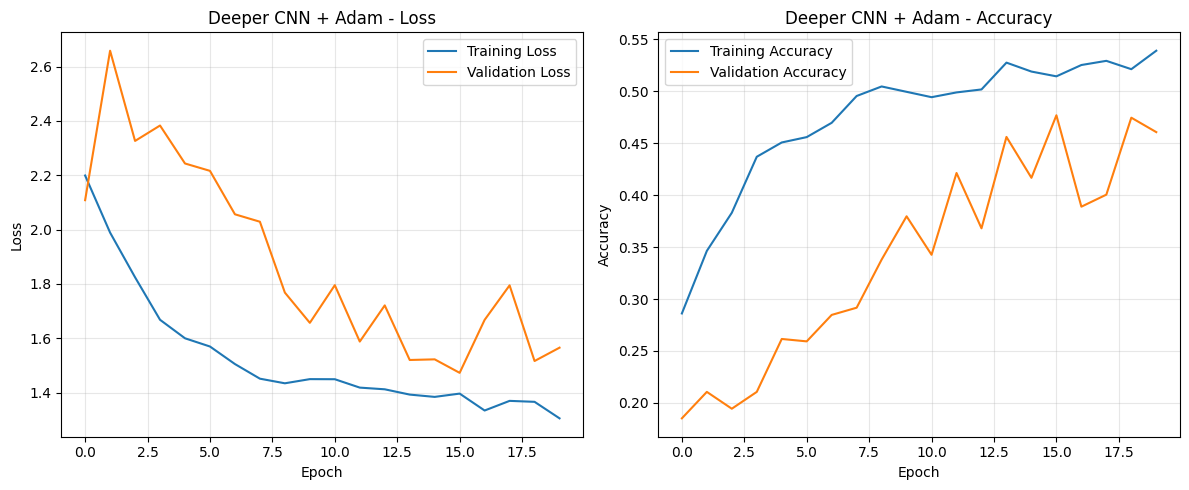


Deeper CNN Adam Results
------------------------------------------------------------
Loss      : 1.9760
Accuracy  : 0.3475
Precision : 0.3328
Recall    : 0.3475
F1-score  : 0.2673

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       1.00      0.12      0.22        16
      basal cell carcinoma       0.38      0.69      0.49        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.17      0.12      0.14        16
                     nevus       0.48      0.88      0.62        16
pigmented benign keratosis       0.24      0.62      0.34        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       1.00      0.67      0.80         3

                  accuracy                           0.35       118
                 macro avg       0.36      0.

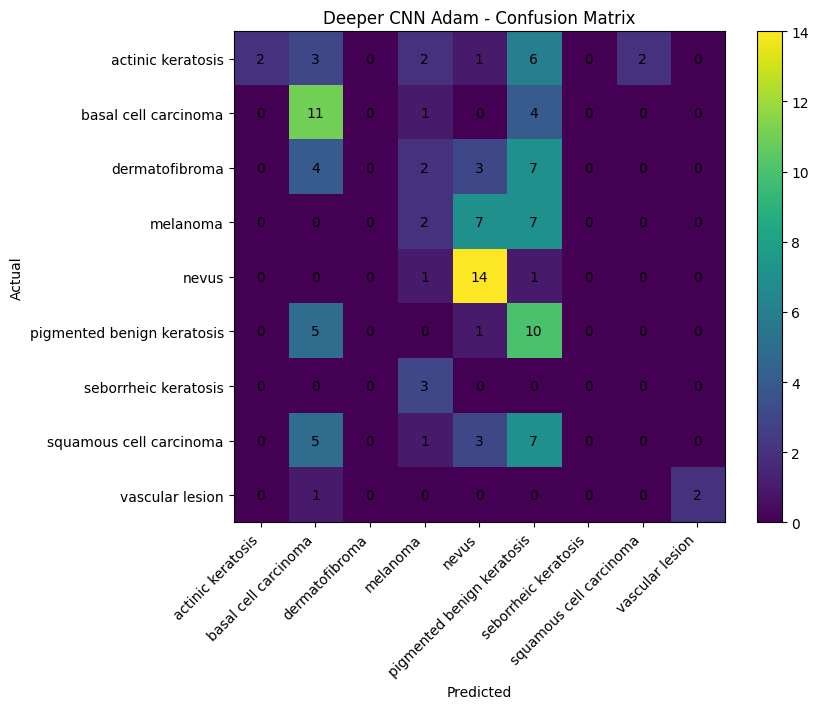

In [18]:
# ============================================================
# 3.2 TRAIN DEEPER CNN WITH ADAM
# ============================================================

deeper_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('deeper_adam_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

start_time = time.time()
deeper_history = deeper_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_SCRATCH,
    callbacks=callbacks_deeper,
    verbose=1
)
deeper_training_time = time.time() - start_time
print(f'Deeper CNN training time: {deeper_training_time:.2f} seconds')

plot_history(deeper_history, 'Deeper CNN + Adam', 'deeper_adam_curves.png')
deeper_results = evaluate_model(deeper_model, test_generator, 'Deeper CNN Adam')

## 4. Experimentation and Comparative Analysis

This section compares optimizers and performs an ablation study by removing dropout.

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.1961 - loss: 2.4187 - val_accuracy: 0.1991 - val_loss: 322.5782 - learning_rate: 0.0100
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 50s 905ms/step - accuracy: 0.2443 - loss: 2.0081 - val_accuracy: 0.1644 - val_loss: 11.5376 - learning_rate: 0.0100
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 50s 895ms/step - accuracy: 0.3033 - loss: 1.9064 - val_accuracy: 0.2199 - val_loss: 2.7311 - learning_rate: 0.0100
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 49s 890ms/step - accuracy: 0.3802 - loss: 1.7830 - val_accuracy: 0.1829 - val_loss: 2.2090 - learning_rate: 0.0100
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 50s 902ms/step - accuracy: 0.4048 - loss: 1.6893 - val_accuracy: 0.2454 - val_loss: 2.2048 - learning_rate: 0.0100
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 51s 922ms/step - accuracy: 0.4163 - loss: 1.6617 - val_accuracy: 0.2755 - val_loss: 2.0159 - learning_rate: 0.0100
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 51s 913ms/step - accuracy: 0.4169 - loss: 1.

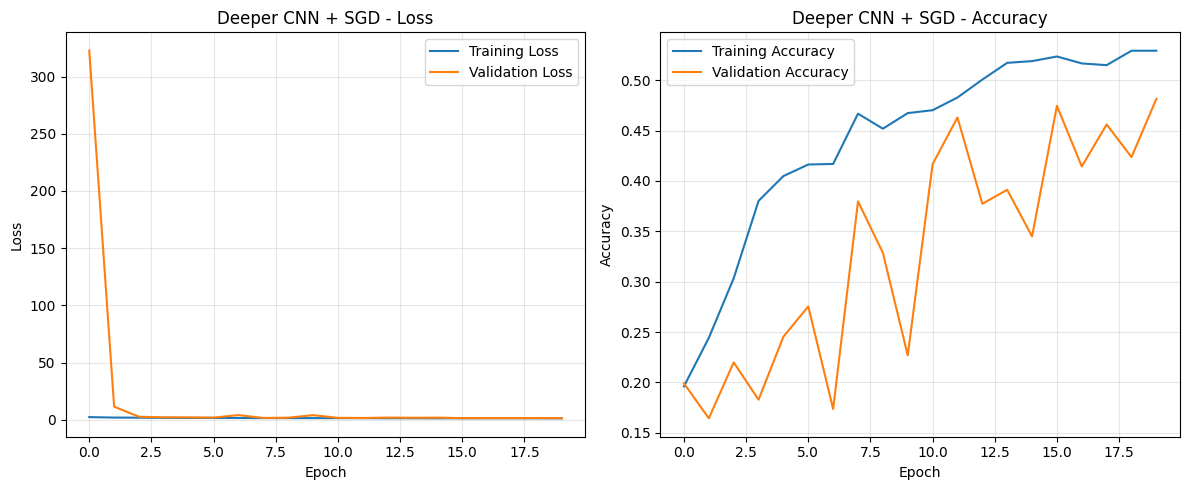


Deeper CNN SGD Results
------------------------------------------------------------
Loss      : 2.1114
Accuracy  : 0.3390
Precision : 0.2291
Recall    : 0.3390
F1-score  : 0.2456

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.35      0.75      0.48        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.17      0.12      0.14        16
                     nevus       0.50      0.88      0.64        16
pigmented benign keratosis       0.24      0.56      0.34        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.33      0.06      0.11        16
           vascular lesion       0.50      0.67      0.57         3

                  accuracy                           0.34       118
                 macro avg       0.23      0.3

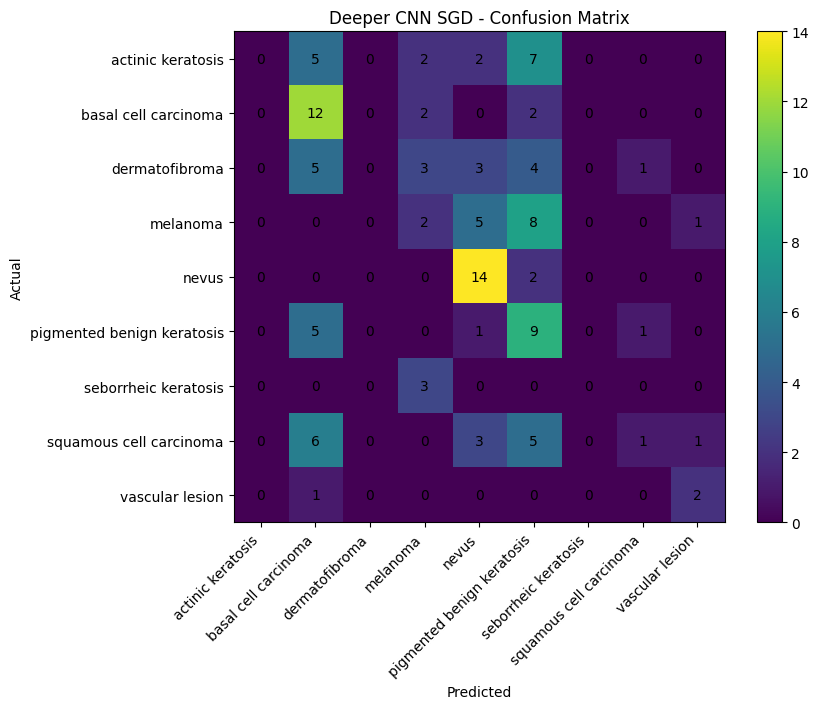

In [30]:
# ============================================================
# 4.1 OPTIMIZER COMPARISON: SGD VS ADAM
# ============================================================

sgd_model = build_deeper_model(input_shape=IMG_SIZE + (3,), num_classes=num_classes)
sgd_model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_sgd = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

start_time = time.time()
sgd_history = sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_SCRATCH,
    callbacks=callbacks_sgd,
    verbose=1
)
sgd_training_time = time.time() - start_time
print(f'SGD training time: {sgd_training_time:.2f} seconds')

plot_history(sgd_history, 'Deeper CNN + SGD', 'deeper_sgd_curves.png')
sgd_results = evaluate_model(sgd_model, test_generator, 'Deeper CNN SGD')

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.3928 - loss: 1.7252 - val_accuracy: 0.1690 - val_loss: 2.7109 - learning_rate: 5.0000e-04
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 52s 950ms/step - accuracy: 0.4839 - loss: 1.4732 - val_accuracy: 0.1690 - val_loss: 3.7022 - learning_rate: 5.0000e-04
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 51s 924ms/step - accuracy: 0.5247 - loss: 1.3678 - val_accuracy: 0.1690 - val_loss: 3.1609 - learning_rate: 5.0000e-04
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 51s 931ms/step - accuracy: 0.5367 - loss: 1.3225 - val_accuracy: 0.1991 - val_loss: 2.3246 - learning_rate: 5.0000e-04
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 50s 915ms/step - accuracy: 0.5459 - loss: 1.2779 - val_accuracy: 0.1921 - val_loss: 2.7755 - learning_rate: 5.0000e-04
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 50s 907ms/step - accuracy: 0.5459 - loss: 1.2434 - val_accuracy: 0.2176 - val_loss: 3.1670 - learning_rate: 5.0000e-04
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 54s 991ms/step - accura

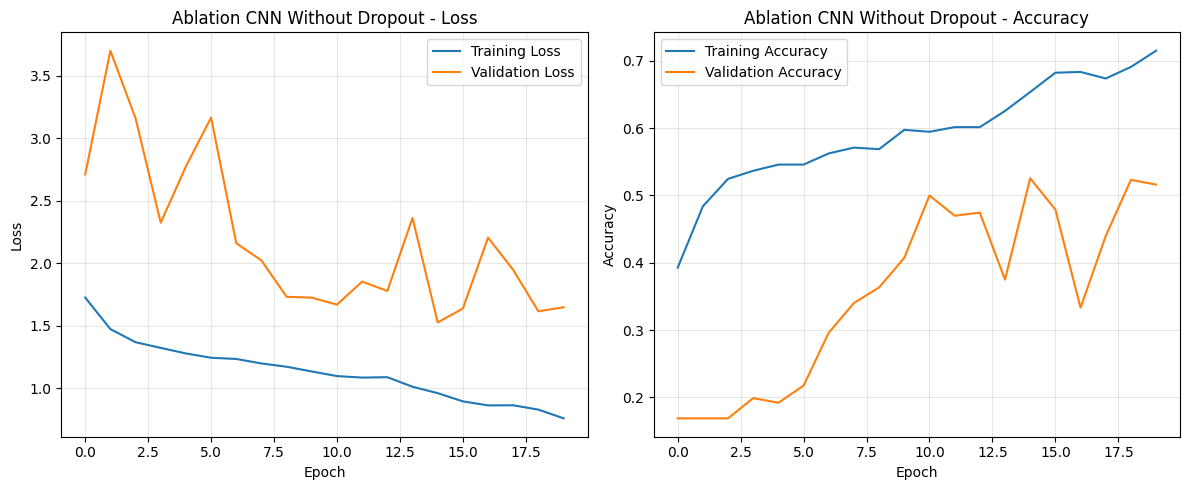


Ablation No Dropout Results
------------------------------------------------------------
Loss      : 2.1440
Accuracy  : 0.3644
Precision : 0.3743
Recall    : 0.3644
F1-score  : 0.3123

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.35      0.44      0.39        16
            dermatofibroma       0.75      0.19      0.30        16
                  melanoma       0.24      0.25      0.24        16
                     nevus       0.33      0.62      0.43        16
pigmented benign keratosis       0.35      0.81      0.49        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.60      0.19      0.29        16
           vascular lesion       0.75      1.00      0.86         3

                  accuracy                           0.36       118
                 macro avg       0.37    

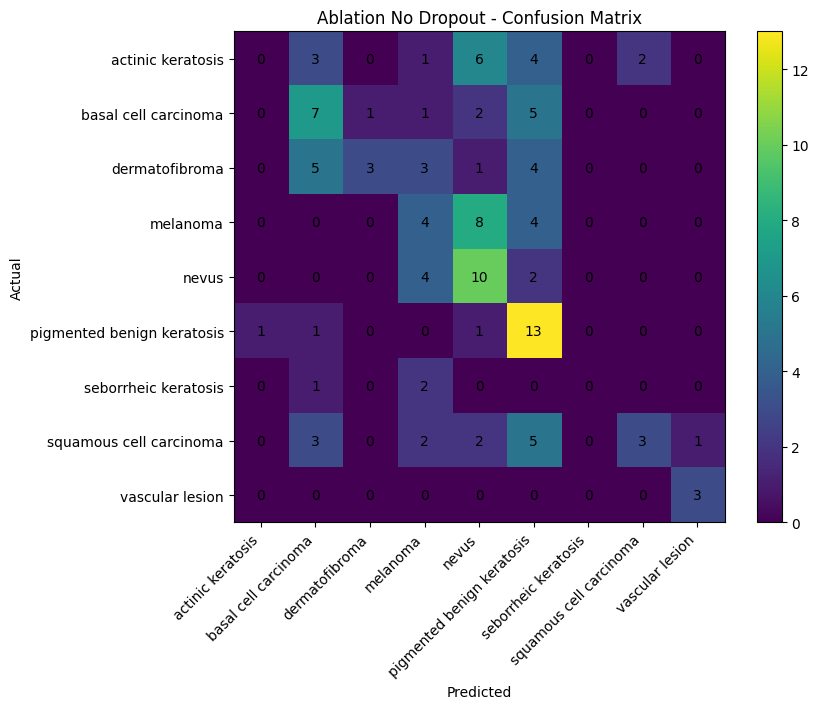

In [20]:
# ============================================================
# 4.2 ABLATION STUDY: REMOVE DROPOUT
# ============================================================

ablation_model = build_deeper_model(input_shape=IMG_SIZE + (3,), num_classes=num_classes, dropout=False, batch_norm=True)
ablation_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ablation = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

start_time = time.time()
ablation_history = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_SCRATCH,
    callbacks=callbacks_ablation,
    verbose=1
)
ablation_training_time = time.time() - start_time
print(f'Ablation model training time: {ablation_training_time:.2f} seconds')

plot_history(ablation_history, 'Ablation CNN Without Dropout', 'ablation_no_dropout_curves.png')
ablation_results = evaluate_model(ablation_model, test_generator, 'Ablation No Dropout')

In [2]:
# ============================================================
# BASIC SETTINGS
# ============================================================

DATASET_ROOT = "/content/drive/MyDrive/AI & Machine Learning/Coursework/Coursework/Skin Cancer Classification"

TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR = os.path.join(DATASET_ROOT, "Test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
SEED = 42

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

Train exists: False
Test exists: False


In [3]:
# ============================================================
# REQUIRED IMPORTS FOR TRANSFER LEARNING DATA GENERATORS
# ============================================================

import os
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("VAL_SPLIT:", VAL_SPLIT)
print("SEED:", SEED)

TRAIN_DIR: /content/drive/MyDrive/AI & Machine Learning/Coursework/Coursework/Skin Cancer Classification/Train
TEST_DIR: /content/drive/MyDrive/AI & Machine Learning/Coursework/Coursework/Skin Cancer Classification/Test
IMG_SIZE: (224, 224)
BATCH_SIZE: 32
VAL_SPLIT: 0.2
SEED: 42


## 5. Transfer Learning

A pretrained **MobileNetV2** model is used because it is lighter and faster than ResNet50, making it suitable for Google Colab while still benefiting from ImageNet feature representations.

In [8]:
# ============================================================
# 5.1 TRANSFER LEARNING DATA GENERATORS
# ============================================================

transfer_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=VAL_SPLIT
)

transfer_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=VAL_SPLIT
)

transfer_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

transfer_train_gen = transfer_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

transfer_val_gen = transfer_val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

if TEST_DIR:
    transfer_test_gen = transfer_test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
else:
    transfer_test_gen = transfer_val_gen

Found 1744 images belonging to 9 classes.
Found 432 images belonging to 9 classes.
Found 118 images belonging to 9 classes.


In [22]:
# ============================================================
# 5.2 BUILD TRANSFER LEARNING MODEL
# ============================================================

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False

inputs = Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

transfer_model = Model(inputs, outputs, name='MobileNetV2_Transfer')
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,001 (10.00 MB)

 Trainable params: 362,505 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [23]:
# ============================================================
# 5.3 PHASE 1: FEATURE EXTRACTION
# ============================================================

transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_transfer = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('transfer_head_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

transfer_start_time = time.time()
transfer_history_1 = transfer_model.fit(
    transfer_train_gen,
    validation_data=transfer_val_gen,
    epochs=EPOCHS_TRANSFER_HEAD,
    callbacks=callbacks_transfer,
    verbose=1
)
phase1_time = time.time() - transfer_start_time
print(f'Feature extraction training time: {phase1_time:.2f} seconds')

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 935ms/step - accuracy: 0.2271 - loss: 2.5383
Epoch 1: val_accuracy improved from None to 0.34028, saving model to transfer_head_best.keras

Epoch 1: finished saving model to transfer_head_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.2964 - loss: 2.2089 - val_accuracy: 0.3403 - val_loss: 1.7593 - learning_rate: 0.0010
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - accuracy: 0.4229 - loss: 1.7961
Epoch 2: val_accuracy improved from 0.34028 to 0.42824, saving model to transfer_head_best.keras

Epoch 2: finished saving model to transfer_head_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 47s 851ms/step - accuracy: 0.4002 - loss: 1.7817 - val_accuracy: 0.4282 - val_loss: 1.5324 - learning_rate: 0.0010
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.4540 - loss: 1.6024
Epoch 3: val_accuracy improved from 0.42824 to 0.48611, saving model to transfer_head_best.keras

Epoch 3: finished saving model to transfer_head_best

In [24]:
# ============================================================
# 5.4 PHASE 2: FINE-TUNING
# ============================================================

base_model.trainable = True

# Freeze lower layers; fine-tune only top layers.
for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_finetune = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('transfer_finetuned_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

ft_start_time = time.time()
transfer_history_2 = transfer_model.fit(
    transfer_train_gen,
    validation_data=transfer_val_gen,
    epochs=EPOCHS_TRANSFER_FINE,
    callbacks=callbacks_finetune,
    verbose=1
)
phase2_time = time.time() - ft_start_time
total_transfer_time = phase1_time + phase2_time
print(f'Fine-tuning time: {phase2_time:.2f} seconds')
print(f'Total transfer learning time: {total_transfer_time:.2f} seconds')

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 894ms/step - accuracy: 0.4240 - loss: 1.6440
Epoch 1: val_accuracy improved from None to 0.58102, saving model to transfer_finetuned_best.keras

Epoch 1: finished saving model to transfer_finetuned_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.4421 - loss: 1.6167 - val_accuracy: 0.5810 - val_loss: 1.3385 - learning_rate: 1.0000e-05
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.4748 - loss: 1.5105
Epoch 2: val_accuracy did not improve from 0.58102
55/55 ━━━━━━━━━━━━━━━━━━━━ 46s 843ms/step - accuracy: 0.4627 - loss: 1.5237 - val_accuracy: 0.5093 - val_loss: 1.4844 - learning_rate: 1.0000e-05
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - accuracy: 0.4592 - loss: 1.5270
Epoch 3: val_accuracy did not improve from 0.58102
55/55 ━━━━━━━━━━━━━━━━━━━━ 47s 860ms/step - accuracy: 0.4685 - loss: 1.5018 - val_accuracy: 0.4907 - val_loss: 1.6268 - learning_rate: 1.0000e-05
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 

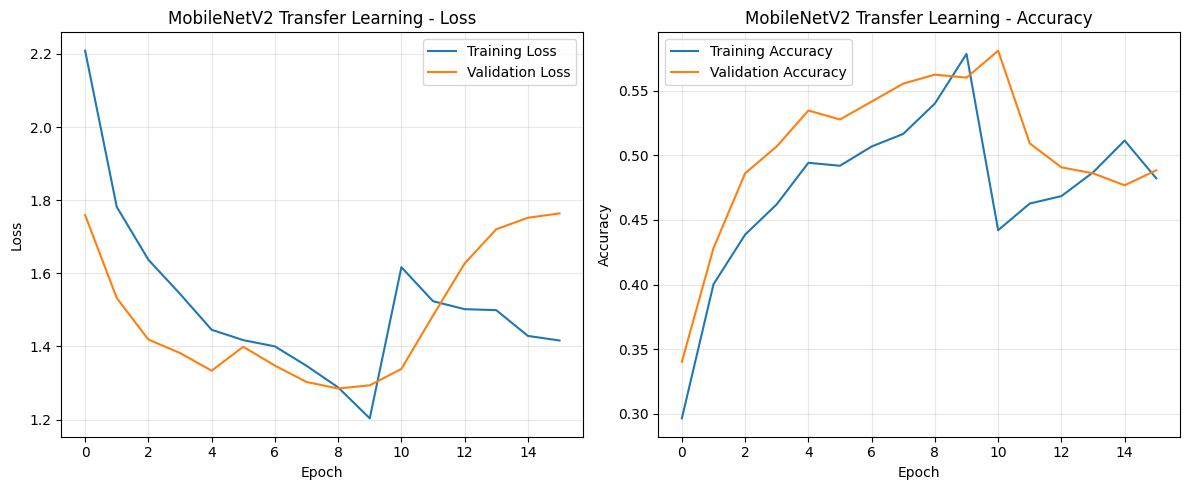


MobileNetV2 Transfer Results
------------------------------------------------------------
Loss      : 2.0277
Accuracy  : 0.3983
Precision : 0.4613
Recall    : 0.3983
F1-score  : 0.3419

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.50      0.06      0.11        16
      basal cell carcinoma       0.34      0.75      0.47        16
            dermatofibroma       1.00      0.12      0.22        16
                  melanoma       0.32      0.44      0.37        16
                     nevus       0.59      0.81      0.68        16
pigmented benign keratosis       0.32      0.50      0.39        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.14      0.06      0.09        16
           vascular lesion       1.00      1.00      1.00         3

                  accuracy                           0.40       118
                 macro avg       0.47   

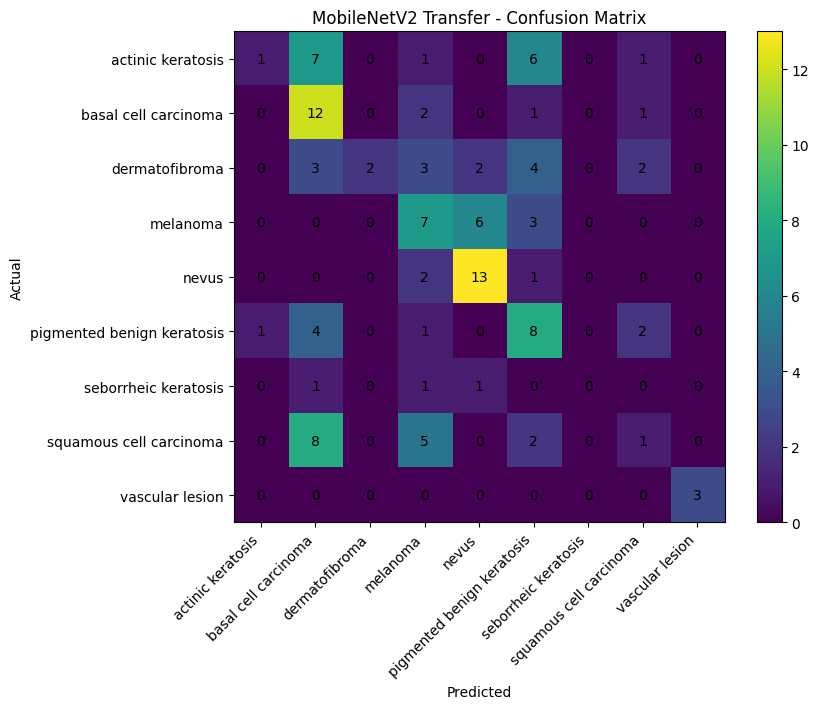

In [25]:
# ============================================================
# 5.5 TRANSFER LEARNING CURVES AND EVALUATION
# ============================================================

combined_history = {
    'loss': transfer_history_1.history['loss'] + transfer_history_2.history['loss'],
    'val_loss': transfer_history_1.history['val_loss'] + transfer_history_2.history['val_loss'],
    'accuracy': transfer_history_1.history['accuracy'] + transfer_history_2.history['accuracy'],
    'val_accuracy': transfer_history_1.history['val_accuracy'] + transfer_history_2.history['val_accuracy']
}

class HistoryObject:
    def __init__(self, history):
        self.history = history

plot_history(HistoryObject(combined_history), 'MobileNetV2 Transfer Learning', 'transfer_learning_curves.png')
transfer_results = evaluate_model(transfer_model, transfer_test_gen, 'MobileNetV2 Transfer')

## 6. Final Comparison, Error Analysis, and Sample Predictions

,Model,Accuracy,Precision,Recall,F1,Loss,Training Time (s)
0,Baseline CNN,0.305085,0.286244,0.305085,0.221960,2.116361,516.873461
1,Deeper CNN + Adam,0.347458,0.332791,0.347458,0.267257,1.975971,1081.382361
2,Deeper CNN + SGD,0.127119,0.019747,0.127119,0.034183,2.349457,485.057516
3,Ablation: No Dropout,0.364407,0.374319,0.364407,0.312283,2.143953,1025.544620
4,MobileNetV2 Transfer,0.398305,0.461330,0.398305,0.341865,2.027730,888.481191


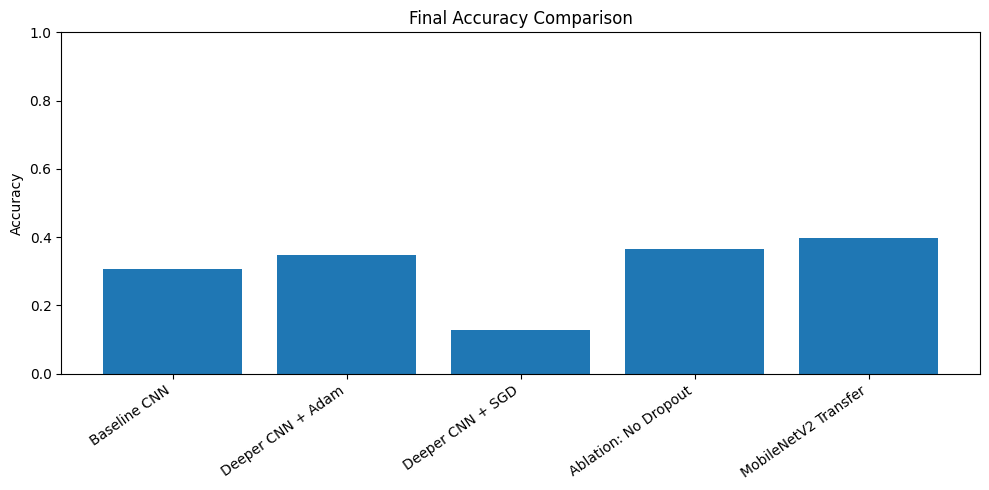

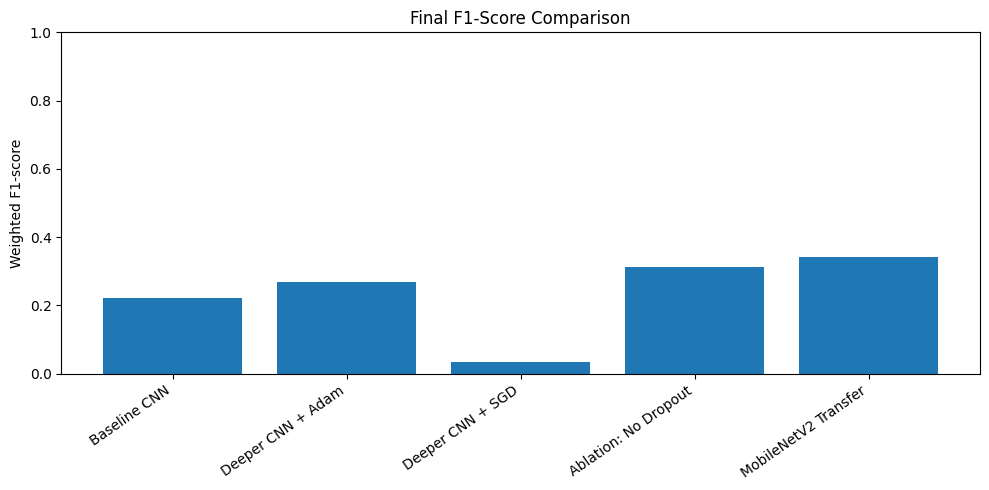

In [26]:
# ============================================================
# 6.1 FINAL MODEL COMPARISON
# ============================================================

results_summary = pd.DataFrame([
    {'Model': 'Baseline CNN', 'Accuracy': baseline_results['accuracy'], 'Precision': baseline_results['precision'], 'Recall': baseline_results['recall'], 'F1': baseline_results['f1'], 'Loss': baseline_results['loss'], 'Training Time (s)': baseline_training_time},
    {'Model': 'Deeper CNN + Adam', 'Accuracy': deeper_results['accuracy'], 'Precision': deeper_results['precision'], 'Recall': deeper_results['recall'], 'F1': deeper_results['f1'], 'Loss': deeper_results['loss'], 'Training Time (s)': deeper_training_time},
    {'Model': 'Deeper CNN + SGD', 'Accuracy': sgd_results['accuracy'], 'Precision': sgd_results['precision'], 'Recall': sgd_results['recall'], 'F1': sgd_results['f1'], 'Loss': sgd_results['loss'], 'Training Time (s)': sgd_training_time},
    {'Model': 'Ablation: No Dropout', 'Accuracy': ablation_results['accuracy'], 'Precision': ablation_results['precision'], 'Recall': ablation_results['recall'], 'F1': ablation_results['f1'], 'Loss': ablation_results['loss'], 'Training Time (s)': ablation_training_time},
    {'Model': 'MobileNetV2 Transfer', 'Accuracy': transfer_results['accuracy'], 'Precision': transfer_results['precision'], 'Recall': transfer_results['recall'], 'F1': transfer_results['f1'], 'Loss': transfer_results['loss'], 'Training Time (s)': total_transfer_time},
])

display(results_summary)
results_summary.to_csv('model_comparison_results.csv', index=False)

plt.figure(figsize=(10, 5))
plt.bar(results_summary['Model'], results_summary['Accuracy'])
plt.title('Final Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=35, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('final_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_summary['Model'], results_summary['F1'])
plt.title('Final F1-Score Comparison')
plt.ylabel('Weighted F1-score')
plt.xticks(rotation=35, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('final_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Total misclassified examples: 71
Example 1
Image: /content/drive/MyDrive/AI & Machine Learning/Coursework/Coursework/Skin Cancer Classification/Test/actinic keratosis/ISIC_0010512.jpg
True label: actinic keratosis
Predicted label: pigmented benign keratosis
Confidence: 0.5434
Possible reason: visually similar class features, low image quality, class imbalance, or insufficient class-specific samples.

Example 2
Image: /content/drive/MyDrive/AI & Machine Learning/Coursework/Coursework/Skin Cancer Classification/Test/actinic keratosis/ISIC_0010889.jpg
True label: actinic keratosis
Predicted label: melanoma
Confidence: 0.5368
Possible reason: visually similar class features, low image quality, class imbalance, or insufficient class-specific samples.

Example 3
Image: /content/drive/MyDrive/AI & Machine Learning/Coursework/Coursework/Skin Cancer Classification/Test/actinic keratosis/ISIC_0024468.jpg
True label: actinic keratosis
Predicted label: squamous cell carcinoma
Confidence: 0.4543
Po

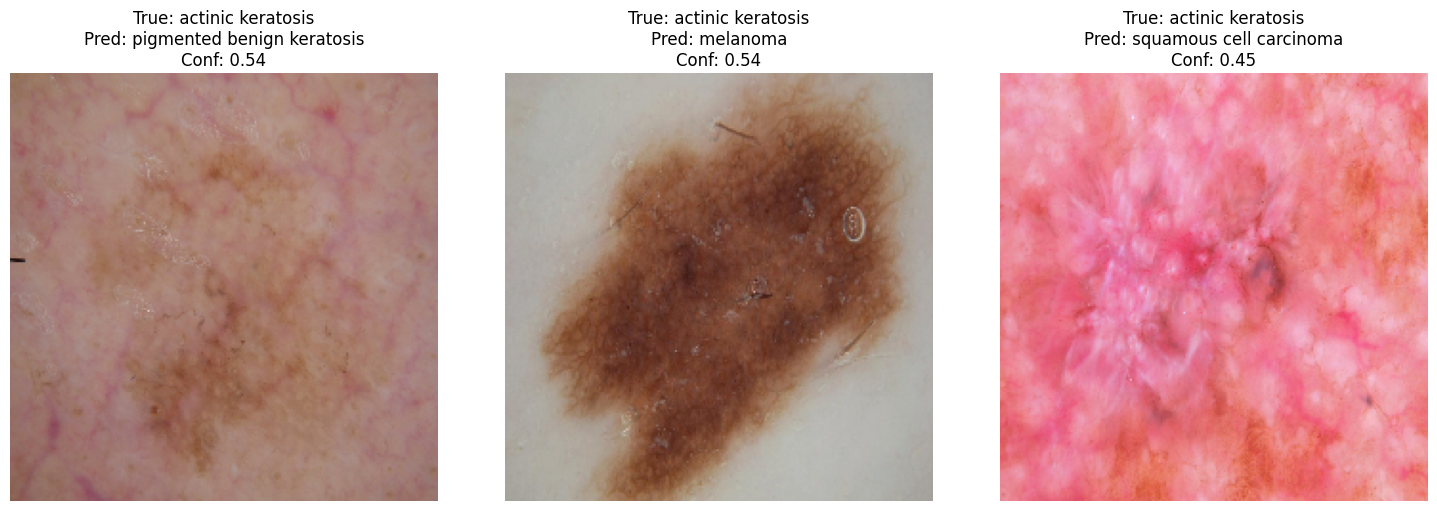

In [27]:
# ============================================================
# 6.2 ERROR ANALYSIS: MISCLASSIFIED EXAMPLES
# ============================================================

best_model = transfer_model
best_gen = transfer_test_gen
best_results = transfer_results

best_gen.reset()
filepaths = best_gen.filepaths
misclassified = np.where(best_results['y_true'] != best_results['y_pred'])[0]

print(f'Total misclassified examples: {len(misclassified)}')

num_show = min(3, len(misclassified))
if num_show > 0:
    plt.figure(figsize=(5 * num_show, 5))
    for i, idx in enumerate(misclassified[:num_show]):
        img = load_img(filepaths[idx], target_size=IMG_SIZE)
        true_label = class_labels[best_results['y_true'][idx]]
        pred_label = class_labels[best_results['y_pred'][idx]]
        confidence = np.max(best_results['pred_probs'][idx])

        plt.subplot(1, num_show, i + 1)
        plt.imshow(img)
        plt.title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}')
        plt.axis('off')

        print(f'Example {i+1}')
        print('Image:', filepaths[idx])
        print('True label:', true_label)
        print('Predicted label:', pred_label)
        print('Confidence:', round(float(confidence), 4))
        print('Possible reason: visually similar class features, low image quality, class imbalance, or insufficient class-specific samples.\n')

    plt.tight_layout()
    plt.savefig('misclassified_examples.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No misclassified examples found in the evaluated set.')

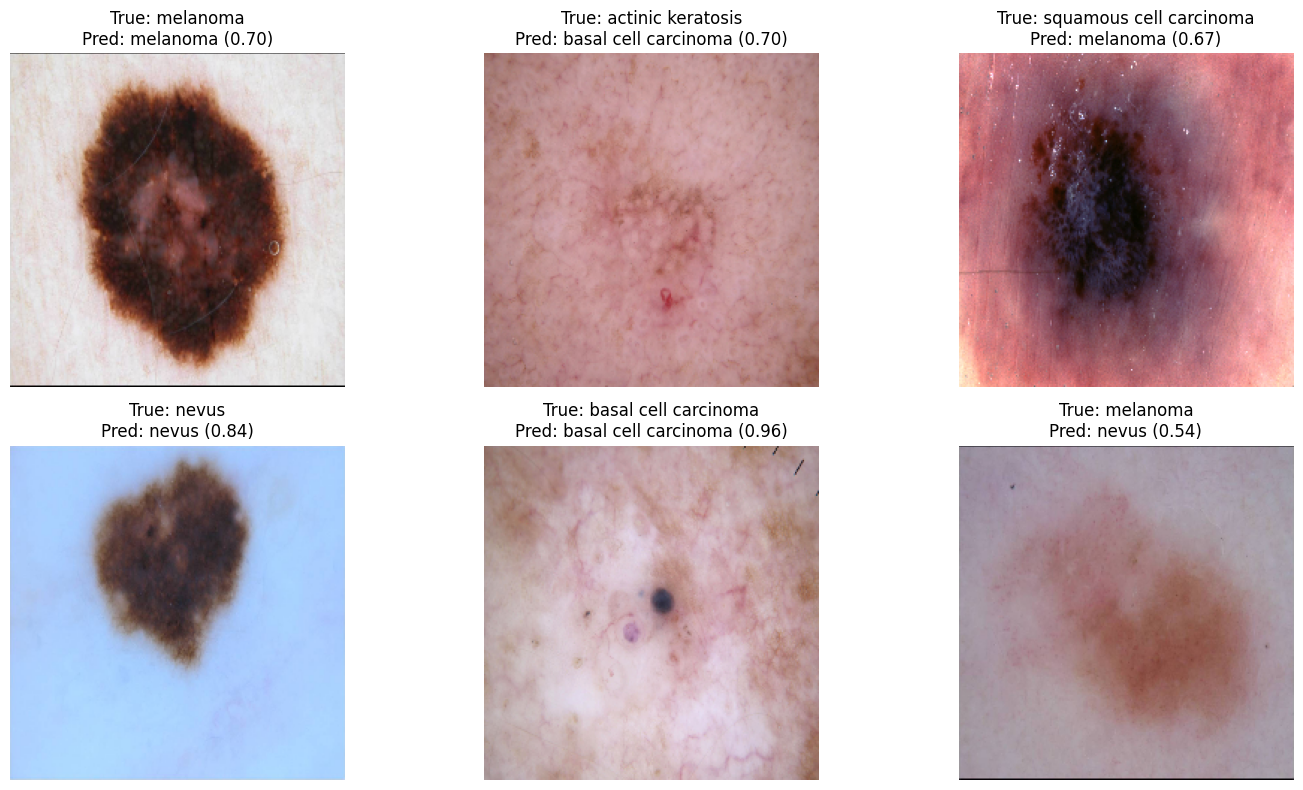

In [28]:
# ============================================================
# 6.3 SAMPLE PREDICTIONS
# ============================================================

best_gen.reset()
filepaths = best_gen.filepaths
indices = np.random.choice(len(filepaths), size=min(6, len(filepaths)), replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    img = load_img(filepaths[idx], target_size=IMG_SIZE)
    arr = img_to_array(img)
    arr_pp = preprocess_input(np.expand_dims(arr.copy(), axis=0))
    pred = best_model.predict(arr_pp, verbose=0)[0]
    pred_idx = np.argmax(pred)
    true_idx = best_gen.classes[idx]

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f'True: {class_labels[true_idx]}\nPred: {class_labels[pred_idx]} ({pred[pred_idx]:.2f})')
    plt.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Report Notes to Write After Running

After running the full notebook, copy the following outputs into your report:

1. Class distribution plots and sample images
2. Augmentation examples
3. Model summaries for baseline, deeper CNN, and transfer model
4. Training/validation accuracy and loss curves
5. Classification reports and confusion matrices
6. Final comparison table
7. Misclassified examples and explanation

Suggested conclusion points:

- Compare baseline and deeper architecture in terms of accuracy, overfitting, and training time.
- Explain whether Adam converged faster than SGD.
- Explain how removing Dropout affected generalization.
- Explain whether MobileNetV2 transfer learning improved performance compared with training from scratch.
- Mention limitations such as class imbalance, limited image samples, and image quality variation.